# Oracle (per-step picker) — workload comparison

**Methods shown**:
- `single:eagle3`, `single:suffix` — single-proposer baselines (from `explorations/`)
- `extension`, `hybrid_e3` (current sim's FT sweep)
- `extension_oracle` (= per-step picker + accept-only verify, from `oracle_v12/`)
- `hybrid_oracle` (= per-(B, τ) sweep + accept-only verify, from `oracle_v12/`)

Each method × workload picks its OWN best across (s, B, FT, τ).


In [8]:
import json, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

WORKLOADS = ['bfcl_v4', 'specbench', 'swebench_verified']
V12_DIR = Path('../results/oracle_v12')
CURRENT_DIR = Path('../results/explorations')

FAMILY_COLORS = {
    'single:eagle3':    '#1f77b4',
    'single:suffix':    '#ffc107',
    'extension':        '#ff7f0e',
    'extension_oracle': '#d62728',
    'hybrid_e3':        '#9467bd',
    'hybrid_oracle':    '#7b3294',
}
PRETTY_LABEL = {
    'single:eagle3':    'EAGLE3',
    'single:suffix':    'Suffix',
    'extension':        'Extension',
    'extension_oracle': 'Extension Oracle',
    'hybrid_e3':        'Hybrid',
    'hybrid_oracle':    'Hybrid Oracle',
}
METHOD_ORDER = ['single:eagle3', 'single:suffix', 'hybrid_e3',
                'hybrid_oracle', 'extension', 'extension_oracle']


In [9]:
# Load v12: extension_oracle (v2 underneath) + hybrid_oracle (hybrid_v2 underneath)
def load_v12():
    rows = []
    for p in V12_DIR.glob('v12_*.json'):
        m = re.match(r'v12_(.+)_s(\d+)k(\d+)\.json', p.name)
        if not m: continue
        wl, s, k = m.group(1), int(m.group(2)), int(m.group(3))
        d = json.load(open(p))
        for ft_key, res in d.get('by_ft', {}).items():
            mft = re.match(r'F([\d.]+)_T([\d.]+)', ft_key)
            F, T = float(mft.group(1)), float(mft.group(2))
            common = dict(workload=wl, steps=s, topk=k,
                          sk_tag=f's={s}k={k}', F=F, T=T)
            # extension_oracle = v2 (per-step picker + accept-only verify)
            v2 = res.get('extension_oracle_v2') or {}
            if isinstance(v2, dict) and 'speedup_real' in v2:
                rows.append({**common, 'method': 'extension_oracle',
                             'B': '(per-step)', 'tau': None,
                             'speedup': v2['speedup_real'],
                             'mat': v2.get('mat', 0)})
            # hybrid_oracle (per-B per-τ)
            for hk, hv in (res.get('hybrid_oracle_v2') or {}).items():
                m_bt = re.match(r'B(\d+)_t([\d.]+)', hk)
                if not m_bt: continue
                B, tau = int(m_bt.group(1)), float(m_bt.group(2))
                rows.append({**common, 'method': 'hybrid_oracle',
                             'B': B, 'tau': tau,
                             'speedup': hv['speedup_real'],
                             'mat': hv.get('mat', 0)})
    return pd.DataFrame(rows)

df_v12 = load_v12()
print(f'v12 rows: {len(df_v12)}')
print(df_v12.groupby(['workload', 'method']).size().to_string())


v12 rows: 288
workload           method          
bfcl_v4            extension_oracle     6
                   hybrid_oracle       90
specbench          extension_oracle     6
                   hybrid_oracle       90
swebench_verified  extension_oracle     6
                   hybrid_oracle       90


In [10]:
# Load current sim: single:eagle3, single:suffix, extension, hybrid_e3
def load_current():
    rows = []
    for p in CURRENT_DIR.glob('sim_*_full.json'):
        m = re.match(r'sim_(.+?)_s(\d+)k(\d+)_full\.json', p.name)
        if not m: continue
        wl, s, k = m.group(1), int(m.group(2)), int(m.group(3))
        if wl not in WORKLOADS: continue
        d = json.load(open(p))
        df = pd.DataFrame(d['latency']['budget_sweep'])
        for col in df.columns:
            if not col.endswith('_speedup_real'): continue
            mn = col[:-len('_speedup_real')]
            if mn.endswith('_always'): continue
            # Drop forbidden extension oracle variants — we use v12's instead
            if mn.startswith('extension_oracle'): continue
            if mn.startswith('extension_hybrid_oracle'): continue
            if mn.startswith('extension_prune_pt_oracle'): continue
            # Map known methods
            if mn == 'eagle3':
                fam = 'single:eagle3'
            elif mn.startswith('suffix_f') or mn == 'suffix':
                fam = 'single:suffix'
            elif mn.startswith('extension_f'):
                fam = 'extension'
            elif mn.startswith('hybrid_e3'):
                fam = 'hybrid_e3'
            else:
                continue
            for idx in df.index:
                spd = df[col].iloc[idx]
                if pd.isna(spd): continue
                B = int(df['budget'].iloc[idx])
                mat = float(df.get(f'{mn}_mat', pd.Series([0])).iloc[idx])
                # Parse F/T if encoded
                ft = re.search(r'_f([\d.]+)_t([\d.]+)', mn)
                F = float(ft.group(1)) if ft else None
                T = float(ft.group(2)) if ft else None
                rows.append({'workload': wl, 'sk_tag': f's={s}k={k}',
                             'method': fam, 'B': B,
                             'F': F, 'T': T, 'tau': None,
                             'speedup': float(spd), 'mat': mat})
    return pd.DataFrame(rows)

df_cur = load_current()
print(f'current rows: {len(df_cur)}')
print(df_cur.groupby(['workload', 'method']).size().to_string())


current rows: 396
workload           method       
bfcl_v4            extension        24
                   hybrid_e3        72
                   single:eagle3    12
                   single:suffix    24
specbench          extension        24
                   hybrid_e3        72
                   single:eagle3    12
                   single:suffix    24
swebench_verified  extension        24
                   hybrid_e3        72
                   single:eagle3    12
                   single:suffix    24


In [11]:
# Per-(workload, method) best across all axes
def best_per_method(wl):
    rows = []
    for fam, src in [('single:eagle3', df_cur), ('single:suffix', df_cur),
                     ('hybrid_e3', df_cur), ('extension', df_cur),
                     ('extension_oracle', df_v12), ('hybrid_oracle', df_v12)]:
        sub = src[(src['workload'] == wl) & (src['method'] == fam)]
        if sub.empty: continue
        best = sub.loc[sub['speedup'].idxmax()].copy()
        rows.append({
            'method': fam, 'pretty': PRETTY_LABEL.get(fam, fam),
            'speedup': float(best['speedup']),
            'mat': float(best.get('mat', 0)),
            'sk_tag': str(best.get('sk_tag', '?')),
            'B': best.get('B'),
            'F': best.get('F'), 'T': best.get('T'),
            'tau': best.get('tau'),
        })
    df = pd.DataFrame(rows)
    df['_o'] = df['method'].map({m:i for i,m in enumerate(METHOD_ORDER)}).fillna(99)
    return df.sort_values('_o').drop(columns='_o').reset_index(drop=True)


=== bfcl_v4 — best per method ===
          pretty  speedup      mat sk_tag          B   F   T  tau
          EAGLE3 2.077232 1.628632  s4k16         64 NaN NaN  NaN
          Suffix 2.261137 1.313245  s2k16          1 4.0 0.0  NaN
          Hybrid 2.641122 1.926244  s2k16         64 4.0 0.0  NaN
   Hybrid Oracle 2.815278 2.221524  s4k16        128 4.0 0.0  5.0
       Extension 3.146458 2.746475  s2k16         16 4.0 0.0  NaN
Extension Oracle 3.875809 3.348203  s4k16 (per-step) 4.0 0.0  NaN


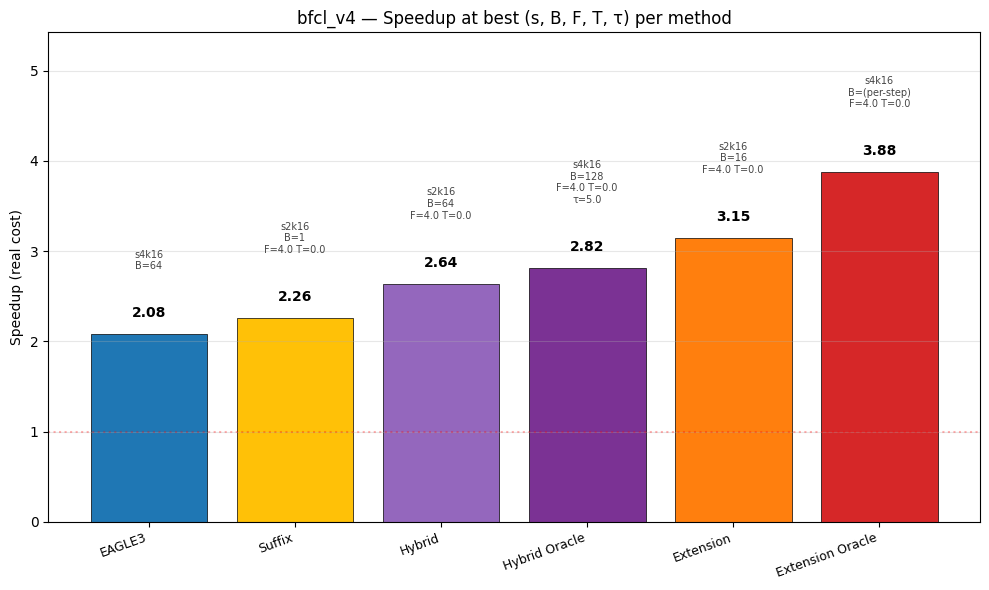

In [12]:
# === bfcl_v4 — Speedup ===
WL = 'bfcl_v4'
best = best_per_method(WL)
print(f'=== {WL} — best per method ===')
print(best[['pretty', 'speedup', 'mat', 'sk_tag', 'B', 'F', 'T', 'tau']].to_string(index=False))

fig, ax = plt.subplots(figsize=(max(10, len(best) * 1.4), 6))
x = np.arange(len(best))
colors = [FAMILY_COLORS.get(m, '#999') for m in best['method']]
ax.bar(x, best['speedup'].values, color=colors, edgecolor='black', linewidth=0.5)
for i, r in best.iterrows():
    spd = r['speedup']
    ax.text(i, spd + 0.04 * best['speedup'].max(), f'{spd:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    parts = [r['sk_tag']]
    bv = r['B']
    # Suffix-only and extension_oracle (per-step) → don't show B
    if r['method'] not in ('single:suffix', 'extension_oracle'):
        if isinstance(bv, str): parts.append(f'B={bv}')
        elif pd.notna(bv): parts.append(f'B={int(bv)}')
    if pd.notna(r.get('F')) and r['F'] is not None:
        parts.append(f'F={r["F"]} T={r["T"]}')
    if pd.notna(r.get('tau')) and r['tau'] is not None:
        parts.append(f'τ={r["tau"]}')
    ax.text(i, spd + 0.18 * best['speedup'].max(), '\n'.join(parts),
            ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(best['pretty'].values, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Speedup (real cost)')
ax.set_title(f'{WL} — Speedup at best (s, B, F, T, τ) per method', fontsize=12)
ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.3)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(top=best['speedup'].max() * 1.40)
plt.tight_layout(); plt.show()


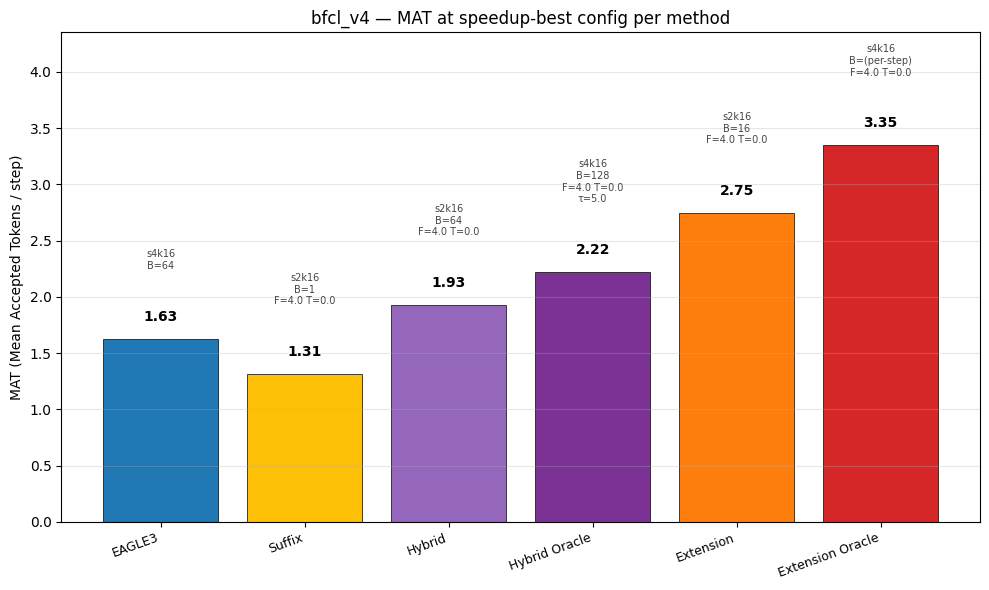

In [13]:
# === bfcl_v4 — MAT (same config as speedup-best) ===
fig, ax = plt.subplots(figsize=(max(10, len(best) * 1.4), 6))
x = np.arange(len(best))
colors = [FAMILY_COLORS.get(m, '#999') for m in best['method']]
ax.bar(x, best['mat'].values, color=colors, edgecolor='black', linewidth=0.5)
for i, r in best.iterrows():
    mat = r['mat']
    ax.text(i, mat + 0.04 * best['mat'].max(), f'{mat:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    parts = [r['sk_tag']]
    bv = r['B']
    # Suffix-only and extension_oracle (per-step) → don't show B
    if r['method'] not in ('single:suffix', 'extension_oracle'):
        if isinstance(bv, str): parts.append(f'B={bv}')
        elif pd.notna(bv): parts.append(f'B={int(bv)}')
    if pd.notna(r.get('F')) and r['F'] is not None:
        parts.append(f'F={r["F"]} T={r["T"]}')
    if pd.notna(r.get('tau')) and r['tau'] is not None:
        parts.append(f'τ={r["tau"]}')
    ax.text(i, mat + 0.18 * best['mat'].max(), '\n'.join(parts),
            ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(best['pretty'].values, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('MAT (Mean Accepted Tokens / step)')
ax.set_title(f'{WL} — MAT at speedup-best config per method', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(top=best['mat'].max() * 1.30)
plt.tight_layout(); plt.show()


=== specbench — best per method ===
          pretty  speedup      mat sk_tag          B   F   T  tau
          EAGLE3 2.332168 1.952721  s4k16         64 NaN NaN  NaN
          Suffix 1.529796 0.560498  s4k16          1 4.0 0.0  NaN
          Hybrid 2.350789 1.967990  s4k16         64 1.0 0.1  NaN
   Hybrid Oracle 2.573650 2.114949  s4k16        128 1.0 0.1  5.0
       Extension 2.442715 1.918707  s2k16         16 4.0 0.0  NaN
Extension Oracle 3.118976 2.602077  s4k16 (per-step) 4.0 0.0  NaN


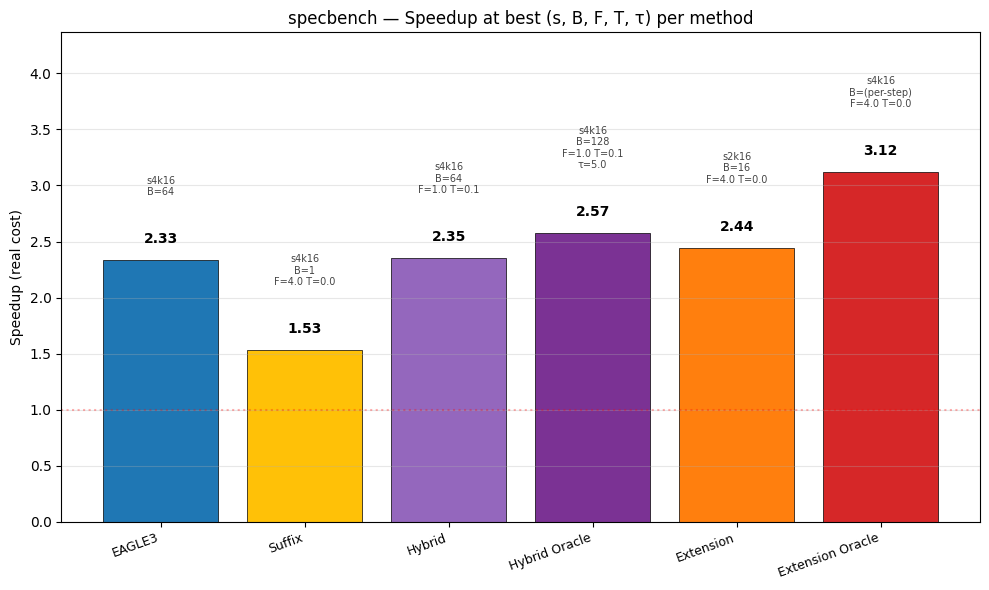

In [14]:
# === specbench — Speedup ===
WL = 'specbench'
best = best_per_method(WL)
print(f'=== {WL} — best per method ===')
print(best[['pretty', 'speedup', 'mat', 'sk_tag', 'B', 'F', 'T', 'tau']].to_string(index=False))

fig, ax = plt.subplots(figsize=(max(10, len(best) * 1.4), 6))
x = np.arange(len(best))
colors = [FAMILY_COLORS.get(m, '#999') for m in best['method']]
ax.bar(x, best['speedup'].values, color=colors, edgecolor='black', linewidth=0.5)
for i, r in best.iterrows():
    spd = r['speedup']
    ax.text(i, spd + 0.04 * best['speedup'].max(), f'{spd:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    parts = [r['sk_tag']]
    bv = r['B']
    # Suffix-only and extension_oracle (per-step) → don't show B
    if r['method'] not in ('single:suffix', 'extension_oracle'):
        if isinstance(bv, str): parts.append(f'B={bv}')
        elif pd.notna(bv): parts.append(f'B={int(bv)}')
    if pd.notna(r.get('F')) and r['F'] is not None:
        parts.append(f'F={r["F"]} T={r["T"]}')
    if pd.notna(r.get('tau')) and r['tau'] is not None:
        parts.append(f'τ={r["tau"]}')
    ax.text(i, spd + 0.18 * best['speedup'].max(), '\n'.join(parts),
            ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(best['pretty'].values, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Speedup (real cost)')
ax.set_title(f'{WL} — Speedup at best (s, B, F, T, τ) per method', fontsize=12)
ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.3)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(top=best['speedup'].max() * 1.40)
plt.tight_layout(); plt.show()


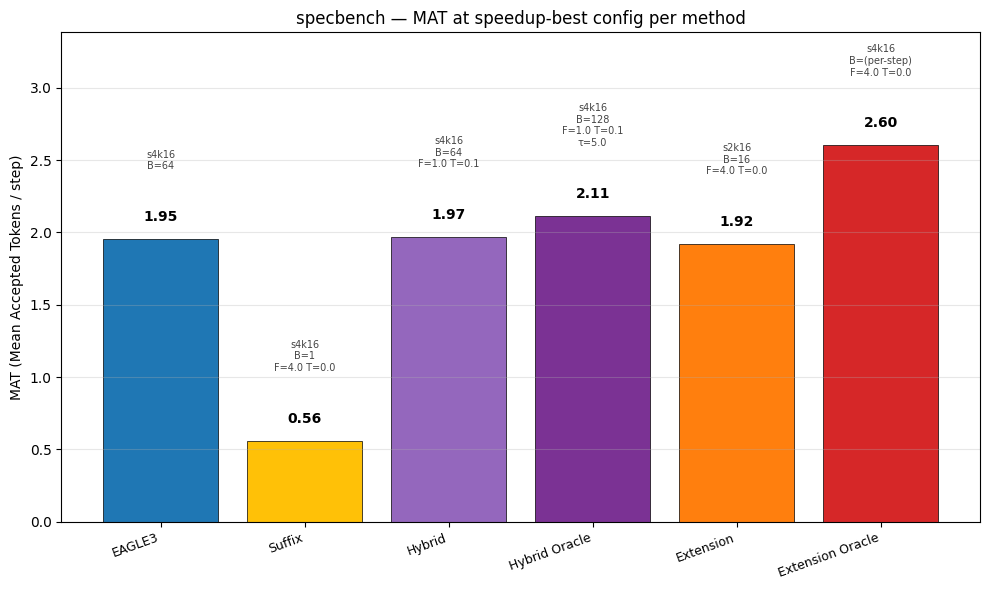

In [15]:
# === specbench — MAT (same config as speedup-best) ===
fig, ax = plt.subplots(figsize=(max(10, len(best) * 1.4), 6))
x = np.arange(len(best))
colors = [FAMILY_COLORS.get(m, '#999') for m in best['method']]
ax.bar(x, best['mat'].values, color=colors, edgecolor='black', linewidth=0.5)
for i, r in best.iterrows():
    mat = r['mat']
    ax.text(i, mat + 0.04 * best['mat'].max(), f'{mat:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    parts = [r['sk_tag']]
    bv = r['B']
    # Suffix-only and extension_oracle (per-step) → don't show B
    if r['method'] not in ('single:suffix', 'extension_oracle'):
        if isinstance(bv, str): parts.append(f'B={bv}')
        elif pd.notna(bv): parts.append(f'B={int(bv)}')
    if pd.notna(r.get('F')) and r['F'] is not None:
        parts.append(f'F={r["F"]} T={r["T"]}')
    if pd.notna(r.get('tau')) and r['tau'] is not None:
        parts.append(f'τ={r["tau"]}')
    ax.text(i, mat + 0.18 * best['mat'].max(), '\n'.join(parts),
            ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(best['pretty'].values, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('MAT (Mean Accepted Tokens / step)')
ax.set_title(f'{WL} — MAT at speedup-best config per method', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(top=best['mat'].max() * 1.30)
plt.tight_layout(); plt.show()


=== swebench_verified — best per method ===
          pretty  speedup      mat sk_tag          B   F   T  tau
          EAGLE3 1.339112 0.533919  s2k16         64 NaN NaN  NaN
          Suffix 4.256662 3.368966  s2k16          1 4.0 0.0  NaN
          Hybrid 4.581362 4.009383  s2k16         64 4.0 0.0  NaN
   Hybrid Oracle 4.782409 4.056477  s2k16        128 4.0 0.0  5.0
       Extension 5.033485 4.974097  s2k16         16 4.0 0.0  NaN
Extension Oracle 6.091813 5.379718  s2k16 (per-step) 4.0 0.0  NaN


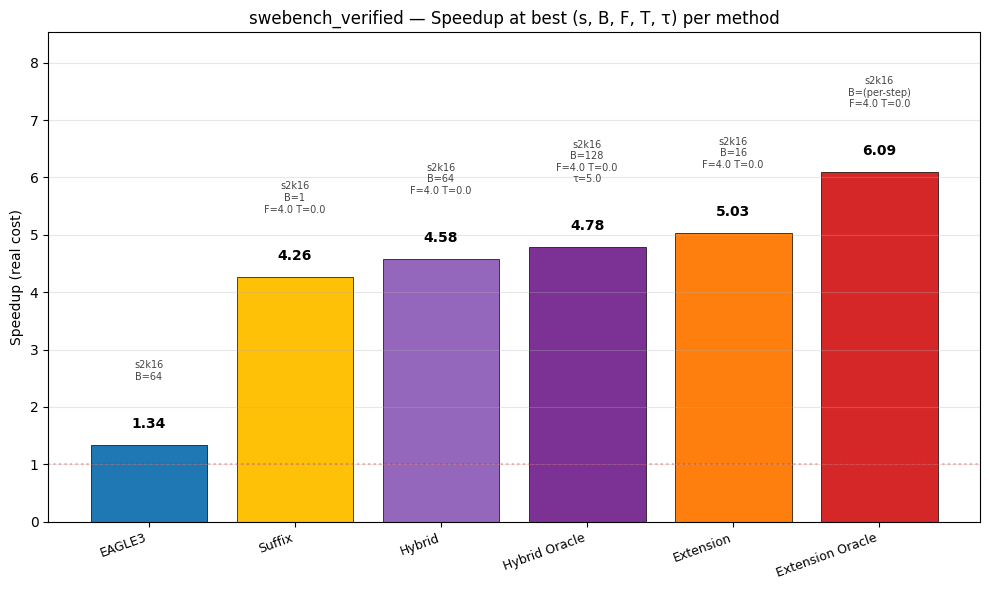

In [16]:
# === swebench_verified — Speedup ===
WL = 'swebench_verified'
best = best_per_method(WL)
print(f'=== {WL} — best per method ===')
print(best[['pretty', 'speedup', 'mat', 'sk_tag', 'B', 'F', 'T', 'tau']].to_string(index=False))

fig, ax = plt.subplots(figsize=(max(10, len(best) * 1.4), 6))
x = np.arange(len(best))
colors = [FAMILY_COLORS.get(m, '#999') for m in best['method']]
ax.bar(x, best['speedup'].values, color=colors, edgecolor='black', linewidth=0.5)
for i, r in best.iterrows():
    spd = r['speedup']
    ax.text(i, spd + 0.04 * best['speedup'].max(), f'{spd:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    parts = [r['sk_tag']]
    bv = r['B']
    # Suffix-only and extension_oracle (per-step) → don't show B
    if r['method'] not in ('single:suffix', 'extension_oracle'):
        if isinstance(bv, str): parts.append(f'B={bv}')
        elif pd.notna(bv): parts.append(f'B={int(bv)}')
    if pd.notna(r.get('F')) and r['F'] is not None:
        parts.append(f'F={r["F"]} T={r["T"]}')
    if pd.notna(r.get('tau')) and r['tau'] is not None:
        parts.append(f'τ={r["tau"]}')
    ax.text(i, spd + 0.18 * best['speedup'].max(), '\n'.join(parts),
            ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(best['pretty'].values, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Speedup (real cost)')
ax.set_title(f'{WL} — Speedup at best (s, B, F, T, τ) per method', fontsize=12)
ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.3)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(top=best['speedup'].max() * 1.40)
plt.tight_layout(); plt.show()


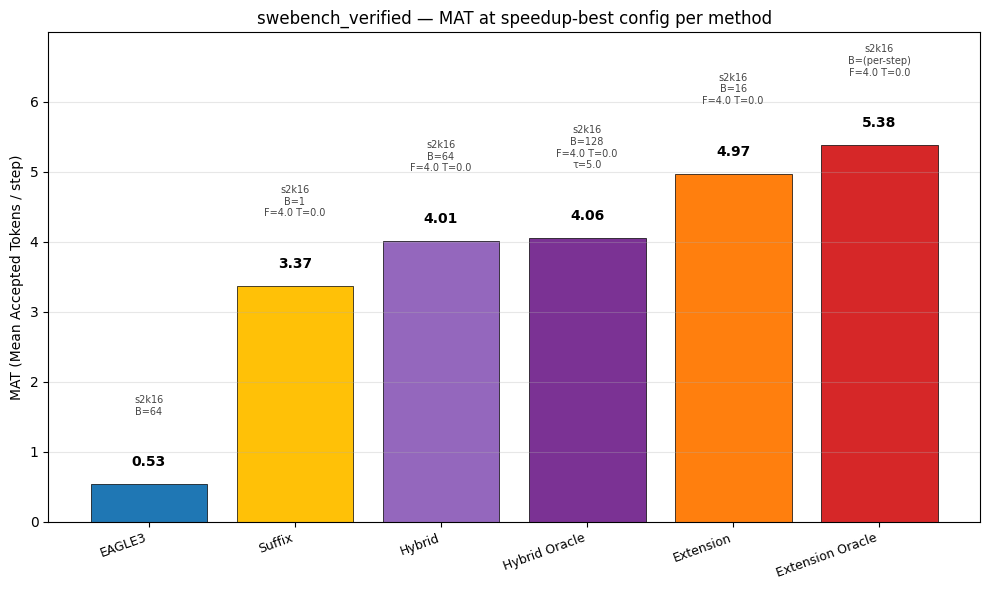

In [17]:
# === swebench_verified — MAT (same config as speedup-best) ===
fig, ax = plt.subplots(figsize=(max(10, len(best) * 1.4), 6))
x = np.arange(len(best))
colors = [FAMILY_COLORS.get(m, '#999') for m in best['method']]
ax.bar(x, best['mat'].values, color=colors, edgecolor='black', linewidth=0.5)
for i, r in best.iterrows():
    mat = r['mat']
    ax.text(i, mat + 0.04 * best['mat'].max(), f'{mat:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    parts = [r['sk_tag']]
    bv = r['B']
    # Suffix-only and extension_oracle (per-step) → don't show B
    if r['method'] not in ('single:suffix', 'extension_oracle'):
        if isinstance(bv, str): parts.append(f'B={bv}')
        elif pd.notna(bv): parts.append(f'B={int(bv)}')
    if pd.notna(r.get('F')) and r['F'] is not None:
        parts.append(f'F={r["F"]} T={r["T"]}')
    if pd.notna(r.get('tau')) and r['tau'] is not None:
        parts.append(f'τ={r["tau"]}')
    ax.text(i, mat + 0.18 * best['mat'].max(), '\n'.join(parts),
            ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(best['pretty'].values, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('MAT (Mean Accepted Tokens / step)')
ax.set_title(f'{WL} — MAT at speedup-best config per method', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(top=best['mat'].max() * 1.30)
plt.tight_layout(); plt.show()
